# Welcome to my Beautiful Dark Twisted Fantasy

In [1]:
from matplotlib import category
import Predictor
import matplotlib.pyplot as plt
import pandas as pd
unprocessedData = Predictor.predict(filePath="C:\\Users\\sophi\\Downloads\\activity (4).xlsx")
DescriptorValues = pd.Categorical(unprocessedData["Description"]).as_ordered()
processedData, thresholds, AmountClassifiers, CategoryClassifiers, DescriptionClassifiers = Predictor.ConvertToValues(unprocessedData)

## Anyway. Here I am consolidating my data. Yahoo!


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Factorized values - array value denotes index of obj, value can be fed to index to get the category
# vals vars are X by 1, Labels vars are <variableCount> by 1
xVals, xLabels = unprocessedData['Description'].factorize() # where the purchase was made
yVals, yLabels = unprocessedData['Amount'].factorize() # how much it cost
zVals, zLabels = unprocessedData['Category'].factorize()# Correlates to which category the purchase should be in
# aggregate description data
xLabels = xLabels.str.slice(0,3)
xVals = xLabels.take(xVals)
data = {
    'xVals' : xVals,
    'yVals' : yVals,
    'zVals' : zVals
}

combinedArray = pd.DataFrame(data)
# group by abbreviated destination
groupedArray = combinedArray.groupby(['xVals'])
# aggregate into a list
groupedArray = groupedArray.agg(list)
groupedArray = pd.DataFrame(groupedArray)

## Now I am make the graph. Very Nice!

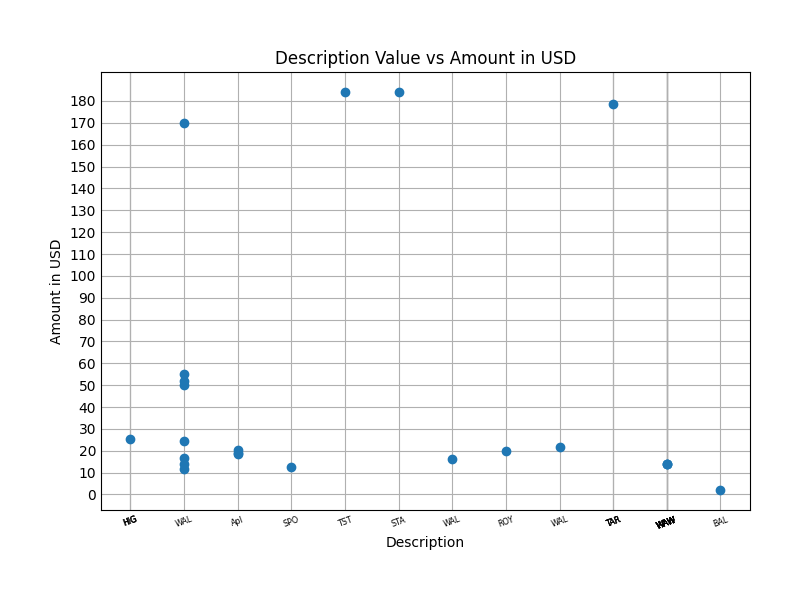

In [14]:
%matplotlib widget
plt.style.use('_mpl-gallery')

# plot:
fig, ax = plt.subplots()
ax.set_title('Description Value vs Amount in USD')
ax.axes.set_xlabel('Description')
ax.set_ylabel('Amount in USD')
ax.set_yticks(range(0, yLabels.astype(int).max(), 10)) # y ticks are in dollars

for label in ax.get_xticklabels():
    label.set_fontsize('xx-small')
    label.set_multialignment('right')
    label.set_rotation(20)

ax.scatter(xVals, yLabels.take(yVals))
ax.set_xticks(pd.Categorical(xVals).codes, labels=xLabels.take(pd.Categorical(xVals).codes))

fig.set_size_inches(8, 6)
fig.set_constrained_layout(True)
fig.set_constrained_layout_pads(w_pad=0.5, h_pad=0.5, hspace=0.5, wspace=0.5)

plt.show()
       